# Bayesian Technosignature Detection

This notebook demonstrates Bayesian model selection for technosignature detection using nested sampling. It compares noise, stationary RFI, and a drifting signal, and in practice behaves as a hard classifier by choosing the most probable model.

Two hypotheses: **H_instr** (noise only) vs **H_rfi** (stationary tone) vs **H_signal** (drifting carrier).

Evidence integrals computed via **dynesty** nested sampling.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import dynesty
from dynesty.utils import resample_equal
import corner
from scipy.stats import norm

In [2]:
rng = np.random.default_rng(seed=1234)
pi  = np.pi

## Step 1 — Synthetic waterfall

We inject a **drifting narrowband carrier** (the technosignature) on top of a **stationary RFI tone** and Gaussian noise.

`snr` controls the signal strength. `f_drift` is the drift rate in bins/integration.

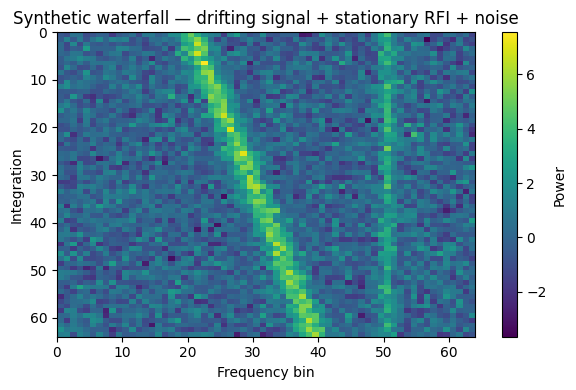

In [13]:
freq_bins = 64
time_int  = 64
sigma     = 1.0   # noise std per pixel
f0        = 20.0  # signal starting frequency (bin)
f_drift   = 0.3   # drift rate (bins per integration)
snr       = 5.1   # signal amplitude in units of sigma  
sigma_spec = 1.5  # Gaussian linewidth of the signal (bins)


# RFI: stationary tone at a different frequency
A_rfi    = 3.0
f_rfi    = 50.0
w_rfi    = 0.8    # RFI linewidth 

freq  = np.arange(freq_bins, dtype=float)
times = np.arange(time_int,  dtype=float)

# Build the true signal (drifting carrier)
spec_true = np.zeros((time_int, freq_bins))
for i, t_i in enumerate(times):
    f_peak     = f0 + f_drift * t_i
    spec_true[i] = snr * sigma * np.exp(-0.5 * ((freq - f_peak) / sigma_spec)**2)

# Build the RFI (same every row -- stationary)
rfi_row = A_rfi * np.exp(-0.5 * ((freq - f_rfi) / w_rfi)**2)
rfi_2d  = np.tile(rfi_row, (time_int, 1))

# Final data: signal + rfi + noise
# FIX: was built twice in two cells, second silently overwriting the first
data2d = spec_true + rfi_2d + rng.normal(0, sigma, (time_int, freq_bins))

plt.figure(figsize=(6, 4))
plt.imshow(data2d, aspect='auto', origin='upper',
           extent=[0, freq_bins, time_int, 0], cmap='viridis')
plt.colorbar(label='Power')
plt.xlabel('Frequency bin')
plt.ylabel('Integration')
plt.title('Synthetic waterfall — drifting signal + stationary RFI + noise')
plt.tight_layout()
plt.show()

## Step 2 — Three parametric models

| Hypothesis | Free parameters | Key feature |
|---|---|---|
| H_instr | σ | flat noise baseline |
| H_rfi | A, f₁, σ | stationary peak, no drift |
| H_signal | A, f₁, ḟ, σ | peak drifts linearly with time |

`sigma_spec` is the known instrument resolution, not a free parameter.

In [4]:
def h_instr(m):
    sigma = m[0]
    return np.zeros((time_int, freq_bins)), sigma

def h_rfi(m):
    A, f1, sigma = m
    # Stationary: drift is zero by construction -- same peak every row
    peak = A * np.exp(-0.5 * ((freq - f1) / sigma_spec)**2)
    return np.tile(peak, (time_int, 1)), sigma

def h_signal(m):
    A, f1, drift, sigma = m
    mu = np.zeros((time_int, freq_bins))
    for i, t_i in enumerate(times):
        fp    = f1 + drift * t_i
        mu[i] = A * np.exp(-0.5 * ((freq - fp) / sigma_spec)**2)
    return mu, sigma

## Step 3 — Gaussian log-likelihood

$$\log \mathcal{L}(\theta) = -\frac{N}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_i (d_i - \mu_i)^2$$

Each pixel is assumed independent with Gaussian noise — valid for time-averaged radio spectra.

In [5]:
def lnlike(model_fn, m):
    mu, s = model_fn(m)
    if s <= 0:
        return -np.inf
    n = data2d.size
    return -0.5 * (n * np.log(2 * pi * s**2) + np.sum((data2d - mu)**2) / s**2)

## Step 4 — Prior transforms for dynesty

dynesty maps the unit hypercube 

The drift prior `|ḟ| < 0.5` is the Keplerian bound — a physically motivated limit on how fast an orbiting transmitter can drift.

In [6]:
def prior_instr(u):
    sigma = 0.01 + 10 * u[0]
    return [sigma]

def prior_rfi(u):
    A     = 0.01 + 20 * u[0]
    f1    = freq.min() + (freq.max() - freq.min()) * u[1]
    sigma = 0.01 + 10 * u[2]
    return [A, f1, sigma]

def prior_signal(u):
    A     = 0.01 + 20 * u[0]
    f1    = freq.min() + (freq.max() - freq.min()) * u[1]
    drift = -0.5 + 1.0 * u[2]   # Keplerian bound: |drift| < 0.5 bins/integration
    sigma = 0.01 + 10 * u[3]
    return [A, f1, drift, sigma]

## Step 5 — Nested sampling

Computing the **evidence integral** 

$$\mathcal{Z}_k = \int \mathcal{L}(\theta)\,\pi(\theta)\,d\theta$$

This gives `logz` and its uncertainty `logzerr` as primary outputs 

In [7]:
def loglike_instr(theta):
    return lnlike(h_instr, theta)

def loglike_rfi(theta):
    return lnlike(h_rfi, theta)

def loglike_signal(theta):
    return lnlike(h_signal, theta)

    
models = {
    "instr":  (loglike_instr,  prior_instr,  1),
    "rfi":    (loglike_rfi,    prior_rfi,    3),
    "signal": (loglike_signal, prior_signal, 4),
}

results = {}
logz    = {}
logzerr = {}

for name, (ll, pt, ndim) in models.items():
    print(f"Running nested sampling: {name} ({ndim} params)...")
    sampler = dynesty.NestedSampler(ll, pt, ndim, nlive=500, sample='rwalk')
    sampler.run_nested(dlogz=0.5, print_progress=False)
    res            = sampler.results
    results[name]  = res
    logz[name]    = res.logz[-1]
    logzerr[name] = res.logzerr[-1]
    print(f"  log Z = {logz[name]:.2f} ± {logzerr[name]:.2f}")

print("\nDone.")

Running nested sampling: instr (1 params)...
  log Z = -7353.06 ± 0.18
Running nested sampling: rfi (3 params)...
  log Z = -7262.54 ± 0.29
Running nested sampling: signal (4 params)...
  log Z = -5901.62 ± 0.37

Done.


## Step 6 — Bayes factors and hypothesis posterior

$$\mathrm{BF}_{ij} = \frac{\mathcal{Z}_i}{\mathcal{Z}_j} = \exp(\log\mathcal{Z}_i - \log\mathcal{Z}_j)$$

$$P(\mathcal{H}_k \mid \mathcal{D}) = \frac{\mathcal{Z}_k\,P(\mathcal{H}_k)}{\sum_j \mathcal{Z}_j\,P(\mathcal{H}_j)}$$

Hypothesis priors reflect the expectation that most candidates are noise or RFI.

Bayes factors vs H_instr:
  BF(H_rfi / H_instr) = 2.04e+39
  BF(H_signal / H_instr) = inf

Posterior over hypotheses:
  P(H_instr    | data) = 0.00  [log Z = -7353.1 ± 0.2]
  P(H_rfi      | data) = 0.00  [log Z = -7262.5 ± 0.3]
  P(H_signal   | data) = 1.00  [log Z = -5901.6 ± 0.4]


/var/folders/l1/1wwyvbr914zfjqmvx6f1db9w0000gn/T/ipykernel_24419/3428696717.py:14: RuntimeWarning: overflow encountered in exp
  bf = np.exp(logz[k] - logz["instr"])


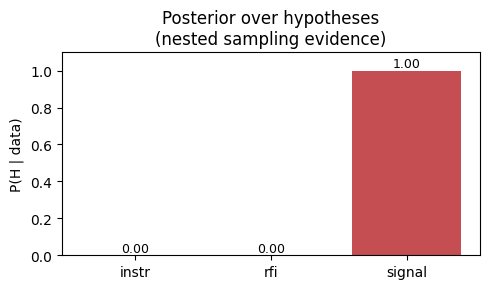

In [8]:
# Hypothesis priors 
H_prior = {"instr": 0.70, "rfi": 0.25, "signal": 0.05}

names  = list(logz.keys())
lz_arr = np.array([logz[k] for k in names])
max_lz = lz_arr.max()

Z    = {k: np.exp(logz[k] - max_lz) for k in names}
den  = sum(Z[k] * H_prior[k] for k in names)
post = {k: Z[k] * H_prior[k] / den for k in names}

print("Bayes factors vs H_instr:")
for k in ["rfi", "signal"]:
    bf = np.exp(logz[k] - logz["instr"])
    print(f"  BF(H_{k} / H_instr) = {bf:.2e}")

print("\nPosterior over hypotheses:")
for k in names:
    print(f"  P(H_{k:8s} | data) = {post[k]:.2f}  "
          f"[log Z = {logz[k]:.1f} ± {logzerr[k]:.1f}]")

# Bar chart
plt.figure(figsize=(5, 3))
plt.bar(names, [post[k] for k in names],
        color=["#4c72b0","#dd8452","#c44e52"])
plt.ylabel("P(H | data)")
plt.title("Posterior over hypotheses\n(nested sampling evidence)")
plt.ylim(0, 1.1)
for i, k in enumerate(names):
    plt.text(i, post[k] + 0.02, f"{post[k]:.2f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Step 7 — Drift rate recovery

The posterior on drift rate under H_signal should be centred near the true value (`f_drift`) and clearly separated from zero.



Drift posterior under H_signal:
  True drift  : 0.3000 bins/integration
  Posterior mean: 0.2983
  Posterior std : 0.0018


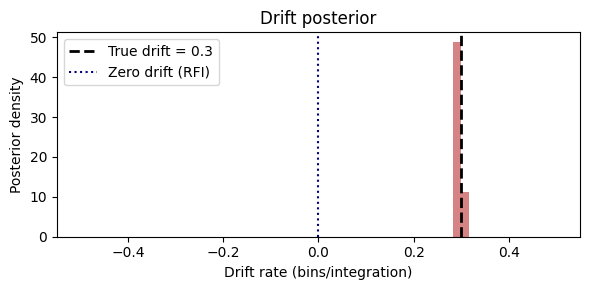

In [9]:
res_s   = results["signal"]
logw    = res_s.logwt - res_s.logz[-1]
weights = np.exp(logw)

samp_s = res_s.samples

drift_samples = samp_s[:, 2]
drift_mean    = np.average(drift_samples, weights=weights)
drift_std     = np.sqrt(np.average((drift_samples - drift_mean)**2, weights=weights))

print(f"Drift posterior under H_signal:")
print(f"  True drift  : {f_drift:.4f} bins/integration")
print(f"  Posterior mean: {drift_mean:.4f}")
print(f"  Posterior std : {drift_std:.4f}")

plt.figure(figsize=(6, 3))
plt.hist(drift_samples, bins=60, weights=weights/weights.sum(),
         density=True, color="#c44e52", alpha=0.7)
plt.axvline(f_drift, color="k", lw=2, ls="--", label=f"True drift = {f_drift}")
plt.axvline(0, color="navy", lw=1.5, ls=":", label="Zero drift (RFI)")
plt.xlabel("Drift rate (bins/integration)")
plt.ylabel("Posterior density")
plt.title("Drift posterior")
plt.legend()
plt.tight_layout()
plt.show()

## Step 8 — Corner plot (H_signal)

Full joint posterior over all four parameters of H_signal -- can our model recover the original inputs for the signal

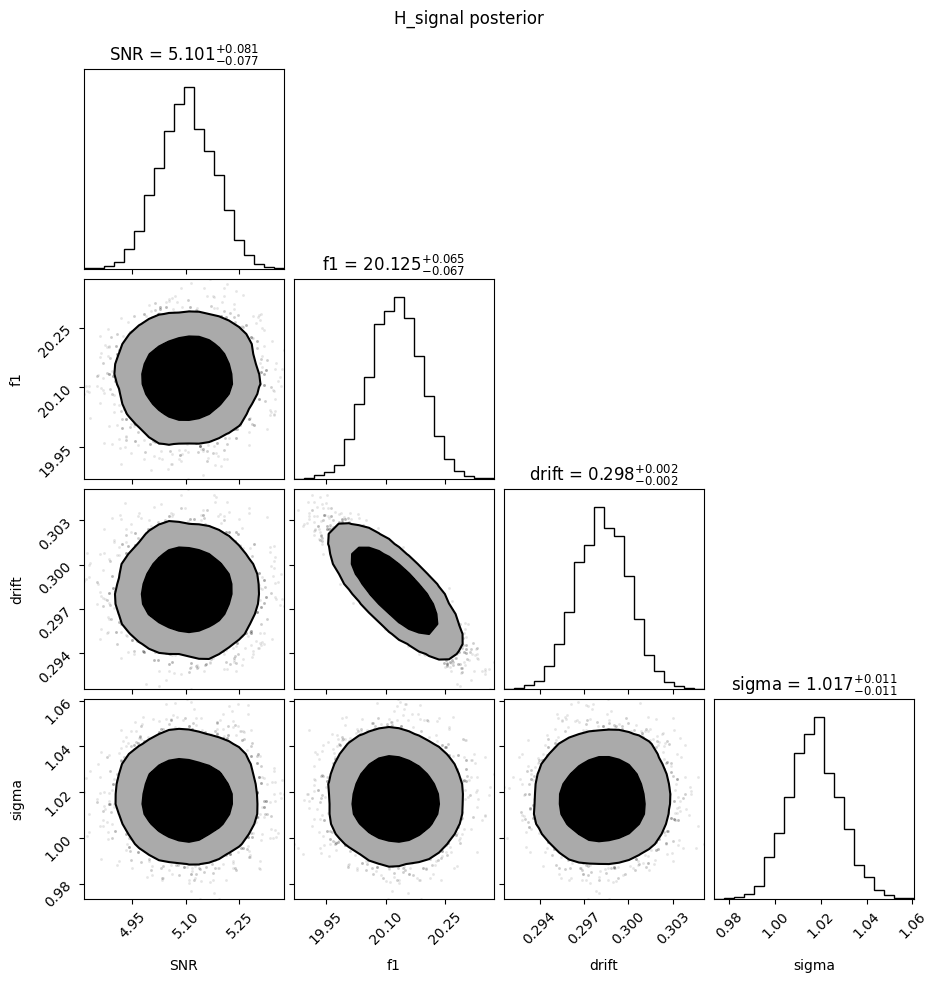

In [14]:
eq_samples = resample_equal(samp_s, weights / weights.sum())
fig = corner.corner(
    eq_samples,
    labels=["SNR", "f1", "drift", "sigma"],
    show_titles=True,
    title_fmt=".3f",
    smooth=1.0,
    levels=(0.68, 0.95),
    fill_contours=True,
)
fig.suptitle("H_signal posterior", y=1.02)
plt.show()